# Neural Network Classification Exercise (Real Data)

## Dataset: Titanic (Kaggle)

**Goal:** predict `Survived` (0/1).

### How to get the dataset

Download Kaggle Titanic `train.csv` and place it in the same folder as this notebook.

- File expected: `train.csv`
- Columns typically include: `Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked`

---


In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score

import tensorflow as tf
import optuna

# Reproducibility
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [ ]:

print(sys.executable)
print("tensorflow:", tf.__version__)
print("protobuf:", gp.__version__)

c:\ProgramData\anaconda3\python.exe
tensorflow: 2.20.0
protobuf: 6.33.2


## 1) Load data


In [3]:
# %% [code]
from pathlib import Path

def load_titanic_csv(path: str | Path = "train.csv") -> pd.DataFrame:
    """Load the Titanic training dataset from a CSV file.

    Args:
        path: Path to Titanic `train.csv`.

    Returns:
        DataFrame containing Titanic rows.

    Raises:
        FileNotFoundError: If the CSV file is not found.
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {p.resolve()}. Download Kaggle Titanic train.csv and place it here."
        )
    return pd.read_csv(p)

df = load_titanic_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2) Exploratory Data Analysis (EDA)


Shape: (891, 12)

Missing rate (top 15):
Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Name           0.000000
Pclass         0.000000
Survived       0.000000
Sex            0.000000
Parch          0.000000
SibSp          0.000000
Fare           0.000000
Ticket         0.000000
dtype: float64


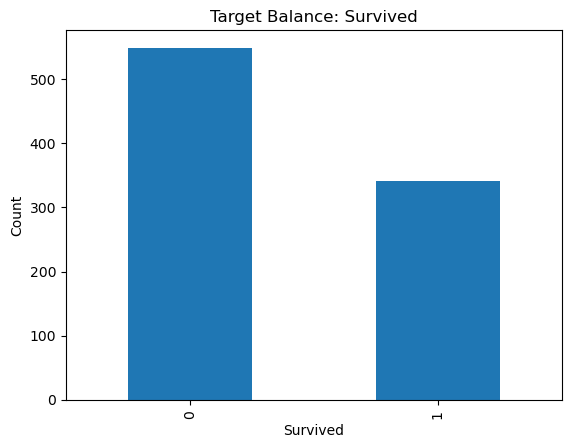

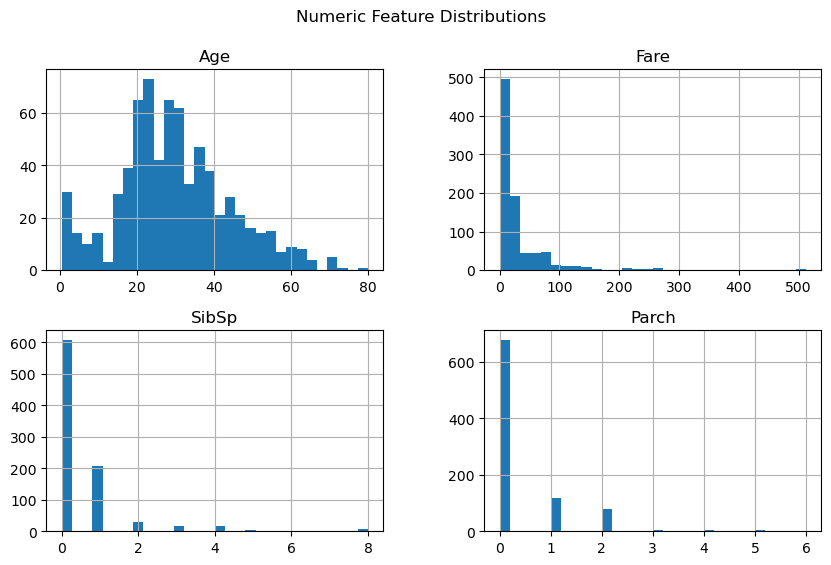


Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [4]:
# %% [code]
def eda_overview(df: pd.DataFrame, target_col: str) -> None:
    """Print basic dataset diagnostics and show a few key plots."""
    print("Shape:", df.shape)
    print("\nMissing rate (top 15):")
    print(df.isna().mean().sort_values(ascending=False).head(15))

    # Target balance
    ax = df[target_col].value_counts().plot(kind="bar", title=f"Target Balance: {target_col}")
    ax.set_xlabel(target_col)
    ax.set_ylabel("Count")
    plt.show()

    # Numeric distributions (only those present)
    numeric_cols = [c for c in ["Age", "Fare", "SibSp", "Parch"] if c in df.columns]
    if numeric_cols:
        df[numeric_cols].hist(bins=30, figsize=(10, 6))
        plt.suptitle("Numeric Feature Distributions")
        plt.show()

eda_overview(df, target_col="Survived")

# Simple group stats (if columns exist)
if "Sex" in df.columns:
    print("\nSurvival rate by Sex:")
    print(df.groupby("Sex")["Survived"].mean().sort_values(ascending=False))

if "Pclass" in df.columns:
    print("\nSurvival rate by Pclass:")
    print(df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False))


## 3) Feature engineering (including interaction features)

We create:

- `FamilySize = SibSp + Parch + 1`
- `IsAlone`
- `FarePerPerson = Fare / FamilySize`
- `Title` from `Name`

Then we add **interaction features** via `PolynomialFeatures` (degree tuned with Optuna).


In [ ]:
# %% [code]
import re

def extract_title(name: str) -> str:
    """Extract a passenger title (e.g., Mr, Mrs, Miss) from the Titanic Name field."""
    m = re.search(r",\s*([^.]*)\.", str(name))
    return m.group(1).strip() if m else "Unknown"

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features to the Titanic dataset.

    Args:
        df: Raw Titanic dataframe.

    Returns:
        Copy of df with additional engineered columns.
    """
    out = df.copy()
    if set(["SibSp", "Parch"]).issubset(out.columns):
        out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
        out["IsAlone"] = (out["FamilySize"] == 1).astype(int)
    else:
        out["FamilySize"] = 1
        out["IsAlone"] = 1

    if "Fare" in out.columns:
        out["FarePerPerson"] = out["Fare"] / out["FamilySize"].replace(0, 1)
    else:
        out["FarePerPerson"] = np.nan

    if "Name" in out.columns:
        out["Title"] = out["Name"].astype(str).apply(extract_title)
        common_titles = out["Title"].value_counts().head(8).index
        out["Title"] = out["Title"].where(out["Title"].isin(common_titles), "Rare")
    else:
        out["Title"] = "Unknown"

    return out

df_fe = add_engineered_features(df)
df_fe[[c for c in ["FamilySize", "IsAlone", "FarePerPerson", "Title"] if c in df_fe.columns]].head()


## 4) Split + preprocessing pipeline (one-hot + scaling + interactions)


In [ ]:
# %% [code]
@dataclass(frozen=True)
class TitanicColumns:
    """Column configuration for the Titanic modeling pipeline."""
    target: str = "Survived"
    cat_cols: Tuple[str, ...] = ("Sex", "Embarked", "Pclass", "Title")
    num_cols: Tuple[str, ...] = ("Age", "Fare", "SibSp", "Parch", "FamilySize", "IsAlone", "FarePerPerson")

def select_existing(df: pd.DataFrame, cols: Tuple[str, ...]) -> list[str]:
    """Filter a list of column names to only those present in a DataFrame."""
    return [c for c in cols if c in df.columns]

def make_preprocessor(cat_cols: list[str], num_cols: list[str], poly_degree: int) -> ColumnTransformer:
    """Create a ColumnTransformer that imputes, expands interactions, scales, and one-hot encodes."""
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])

cfg = TitanicColumns()
cat_cols = select_existing(df_fe, cfg.cat_cols)
num_cols = select_existing(df_fe, cfg.num_cols)

X = df_fe.drop(columns=[cfg.target])
y = df_fe[cfg.target].astype(int).values

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cat_cols, num_cols


## 5) Keras model + Optuna hyperparameter optimization


In [ ]:
# %% [code]
def build_classifier(input_dim: int, n_layers: int, units: int, dropout: float, l2: float, lr: float) -> tf.keras.Model:
    """Build a simple MLP binary classifier in Keras.

    Args:
        input_dim: Number of input features.
        n_layers: Number of hidden layers.
        units: Units per hidden layer.
        dropout: Dropout rate.
        l2: L2 regularization strength.
        lr: Learning rate.

    Returns:
        Compiled Keras model.
    """
    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs
    for _ in range(n_layers):
        x = tf.keras.layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(l2),
        )(x)
        x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"],
    )
    return model

def to_dense(x: Any) -> np.ndarray:
    """Convert scipy sparse matrix to dense numpy array if needed."""
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

def optuna_objective(trial: optuna.Trial) -> float:
    """Optuna objective maximizing validation AUC."""
    poly_degree = trial.suggest_int("poly_degree", 1, 2)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    units = trial.suggest_int("units", 32, 256, step=32)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    l2 = trial.suggest_float("l2", 1e-8, 1e-3, log=True)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    pre = make_preprocessor(cat_cols, num_cols, poly_degree)
    Xtr = to_dense(pre.fit_transform(X_train))
    Xva = to_dense(pre.transform(X_valid))

    model = build_classifier(Xtr.shape[1], n_layers, units, dropout, l2, lr)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=8, restore_best_weights=True
        )
    ]
    # Optional pruning if installed
    try:
        from optuna.integration import TFKerasPruningCallback
        callbacks.append(TFKerasPruningCallback(trial, "val_auc"))
    except Exception:
        pass

    hist = model.fit(
        Xtr, y_train,
        validation_data=(Xva, y_valid),
        epochs=60,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks,
    )
    return float(max(hist.history["val_auc"]))


In [ ]:
# %% [code]
study = optuna.create_study(direction="maximize")
study.optimize(optuna_objective, n_trials=40)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)


## 6) Final retrain with best params + evaluation


In [ ]:
# %% [code]
def train_best_and_evaluate(best_params: Dict[str, Any]) -> Dict[str, float]:
    """Train a final model using best Optuna parameters and evaluate on validation."""
    pre = make_preprocessor(cat_cols, num_cols, int(best_params["poly_degree"]))
    Xtr = to_dense(pre.fit_transform(X_train))
    Xva = to_dense(pre.transform(X_valid))

    model = build_classifier(
        input_dim=Xtr.shape[1],
        n_layers=int(best_params["n_layers"]),
        units=int(best_params["units"]),
        dropout=float(best_params["dropout"]),
        l2=float(best_params["l2"]),
        lr=float(best_params["lr"]),
    )

    model.fit(
        Xtr, y_train,
        validation_data=(Xva, y_valid),
        epochs=120,
        batch_size=int(best_params["batch_size"]),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_auc", mode="max", patience=12, restore_best_weights=True
            )
        ],
        verbose=0,
    )

    proba = model.predict(Xva, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)

    metrics = {
        "val_auc": float(roc_auc_score(y_valid, proba)),
        "val_accuracy": float(accuracy_score(y_valid, pred)),
    }
    return metrics

final_metrics = train_best_and_evaluate(study.best_params)
final_metrics


## Next steps

- Add cross-validation (StratifiedKFold).
- Add calibration (Platt/Isotonic).
- Try embedding for categorical features instead of one-hot.


## Summary: Baseline vs Tuned

This cell prints a **one‑glance comparison** between the baseline model and the Optuna‑tuned model.


In [ ]:

summary = {
    "baseline": baseline_metrics,
    "tuned": final_metrics,
    "improvement_auc": final_metrics["val_auc"] - baseline_metrics["baseline_val_auc"],
    "improvement_accuracy": final_metrics["val_accuracy"] - baseline_metrics["baseline_val_accuracy"],
}
summary
